In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Initial Data Exploration

In [2]:
# Read the CSV files
df_red_raw = pd.read_csv('data/winequality-red.csv', delimiter=';')
df_white_raw = pd.read_csv('data/winequality-white.csv', delimiter=';')

# red_features = df_red_raw.drop('quality', axis=1)
# white_features = df_white_raw.drop('quality', axis=1)

# Rename columns to replace spaces with underscores
df_red_raw.columns = df_red_raw.columns.str.replace(' ', '_')
df_white_raw.columns = df_white_raw.columns.str.replace(' ', '_')

In [3]:
# Inspect the number of rows and columns of red wines
df_red_raw.shape

(1599, 12)

In [4]:
# Inspect the number of rows and columns of white wines
df_red_raw.shape

(1599, 12)

In [5]:
df_red_raw.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
df_red_raw.tail()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [7]:
df_white_raw.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [8]:
df_white_raw.tail()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7
4897,6.0,0.21,0.38,0.8,0.020,22.0,98.0,0.98941,3.26,0.32,11.8,6


In [9]:
# Check for missing values and the data types of each column in red wines
print('Red wines info:')
df_red_raw.info()

Red wines info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1599 non-null   float64
 1   volatile_acidity      1599 non-null   float64
 2   citric_acid           1599 non-null   float64
 3   residual_sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free_sulfur_dioxide   1599 non-null   float64
 6   total_sulfur_dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [10]:
# Check for missing values and the data types of each column in white wines
print('White wines info:')
df_white_raw.info()

White wines info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         4898 non-null   float64
 1   volatile_acidity      4898 non-null   float64
 2   citric_acid           4898 non-null   float64
 3   residual_sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free_sulfur_dioxide   4898 non-null   float64
 6   total_sulfur_dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


<u>**NOTE:** The data has no missing values and all columns are numeric</u>

In [11]:
# Statistical summary
print('Red wines statistical summary:')
df_red_raw.describe()

Red wines statistical summary:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [12]:
# Statistical summary
print('White wines statistical summary:')
df_white_raw.describe()

White wines statistical summary:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


Statistical summaries revealed some insights:
- The minimum value for the `citrict_acid` column is 0. Is 0 a valid value in a wine physiochemical context?
- The minimum value for the `residual_sugar` column 0.6, but the max value is 65.80. Is the max value valid in a physichemical context? 
- There's a big gap between min and max values for columns `free_sulfur_dioxide`, and `total_sulfur_dioxide`

### Univariate Analysis

fixed_acidity
Skew : 0.98


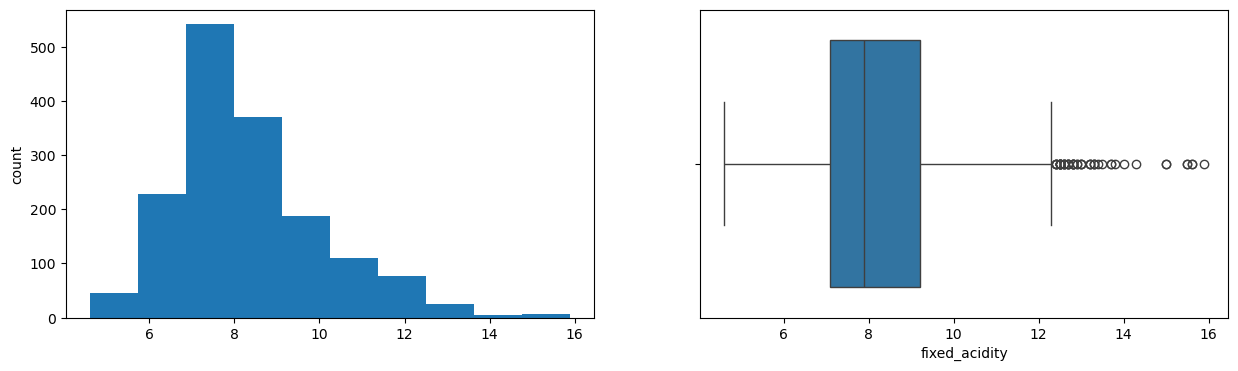

volatile_acidity
Skew : 0.67


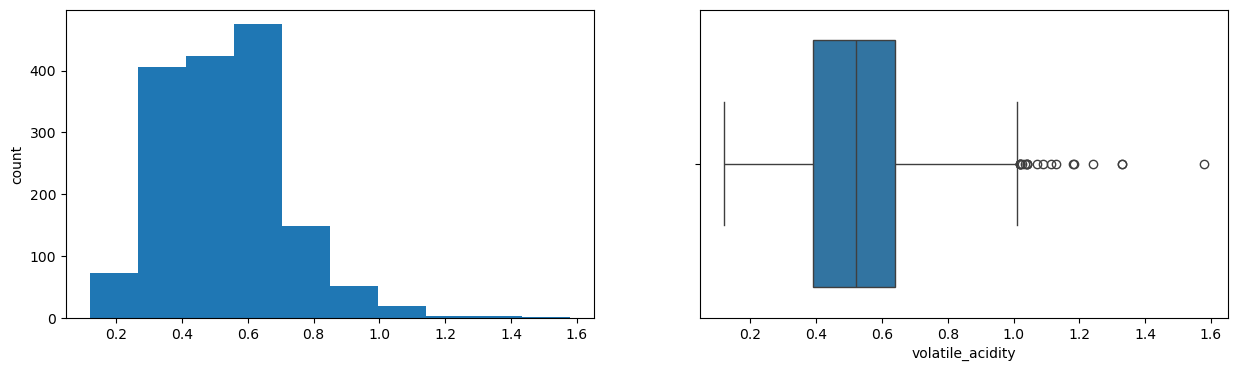

citric_acid
Skew : 0.32


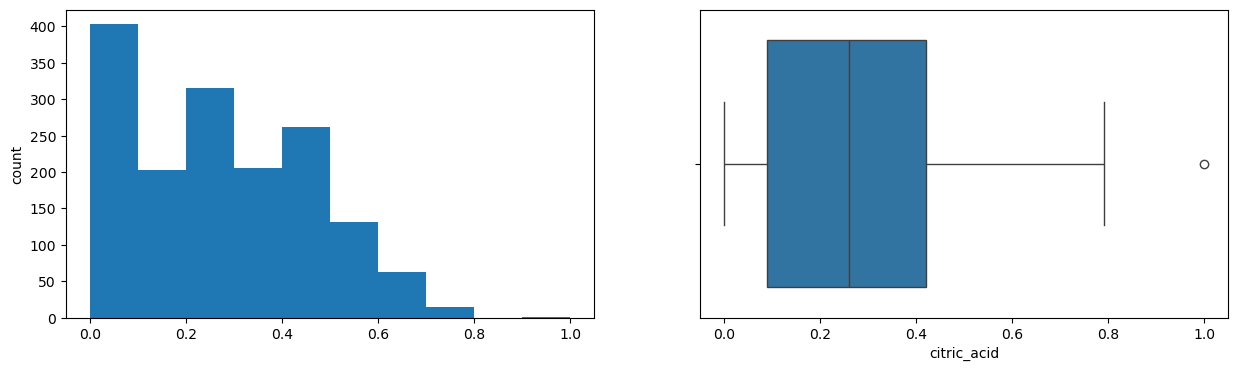

residual_sugar
Skew : 4.54


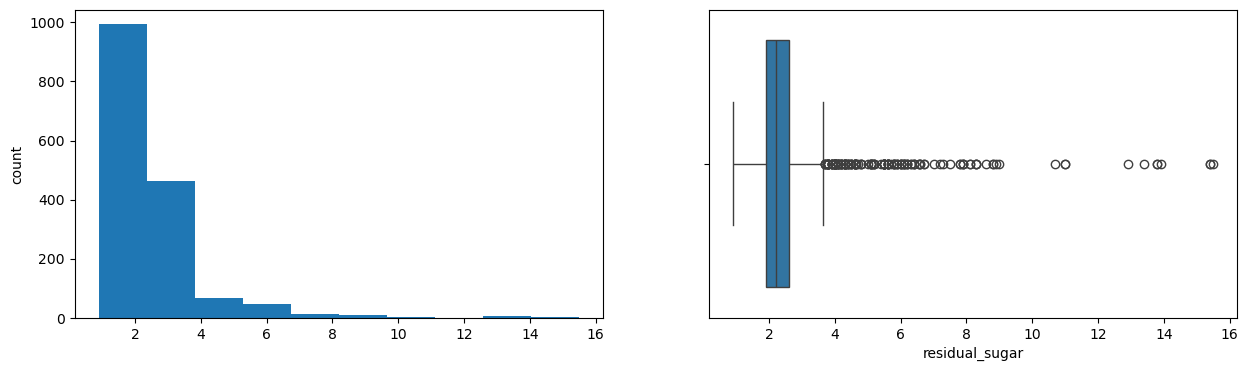

chlorides
Skew : 5.68


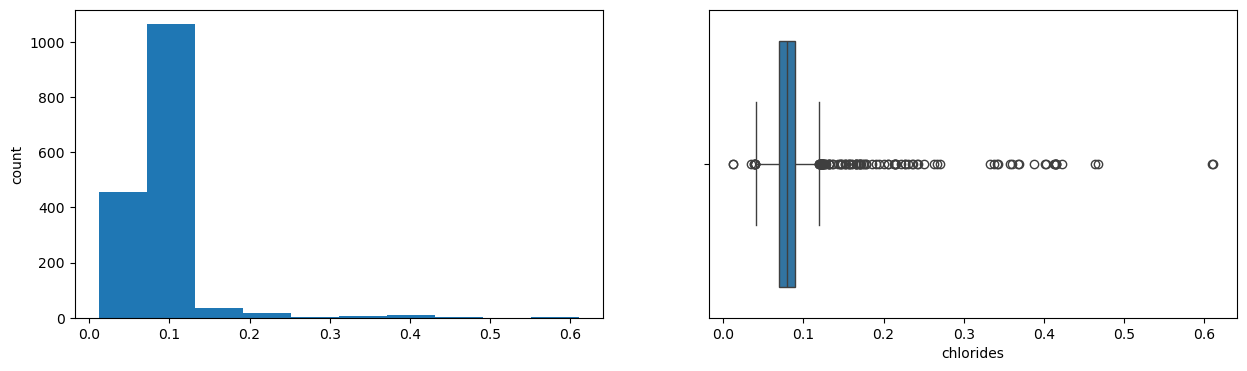

free_sulfur_dioxide
Skew : 1.25


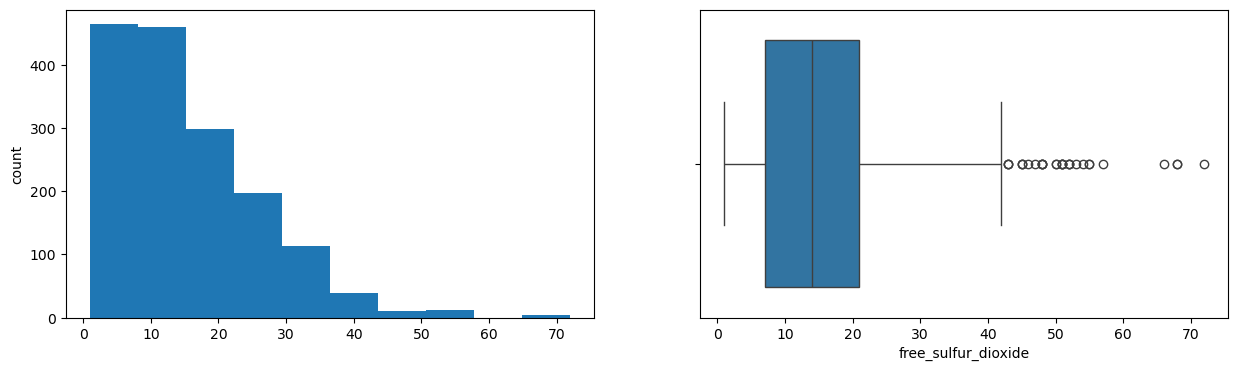

total_sulfur_dioxide
Skew : 1.52


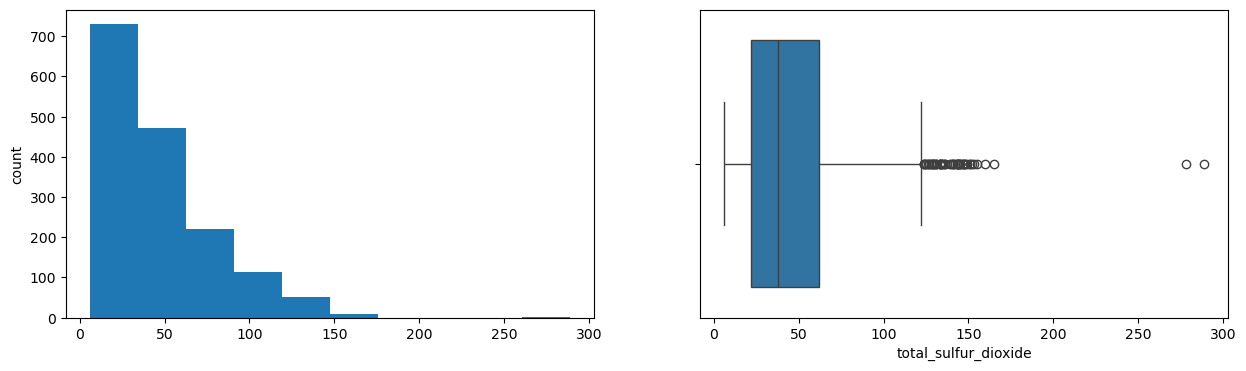

density
Skew : 0.07


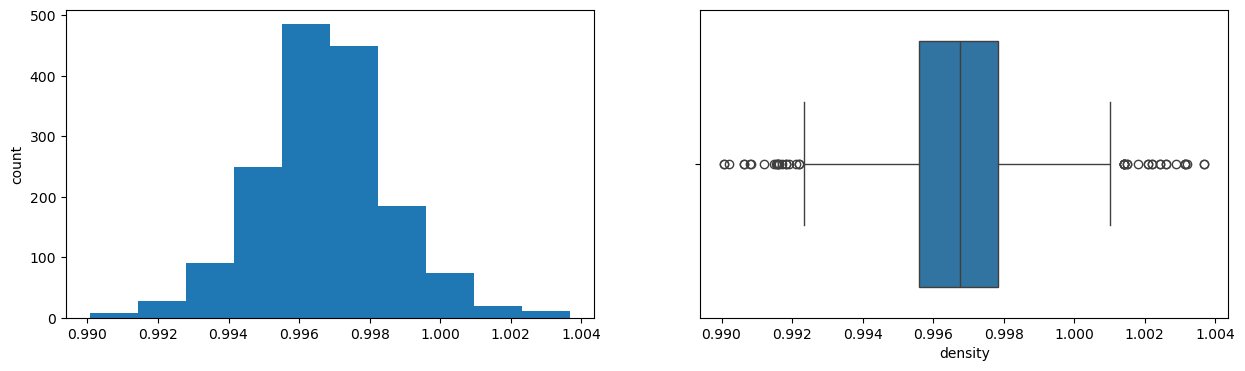

pH
Skew : 0.19


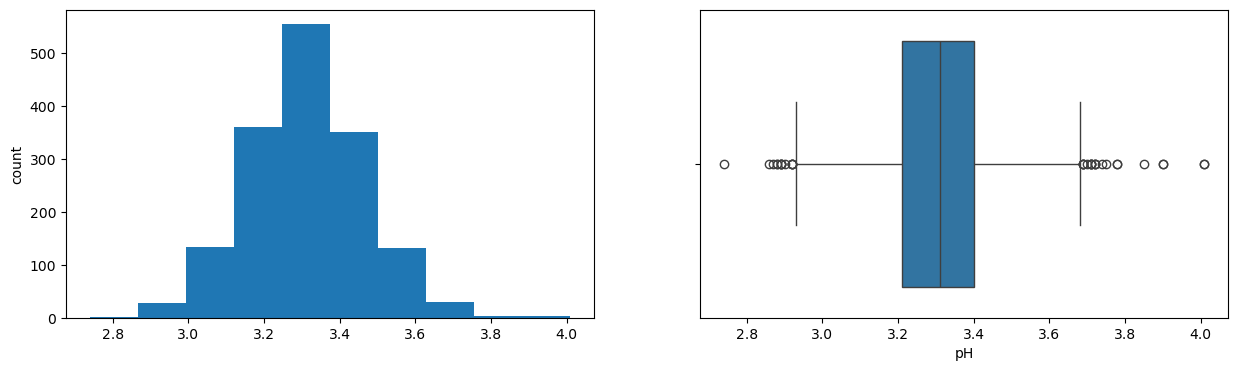

sulphates
Skew : 2.43


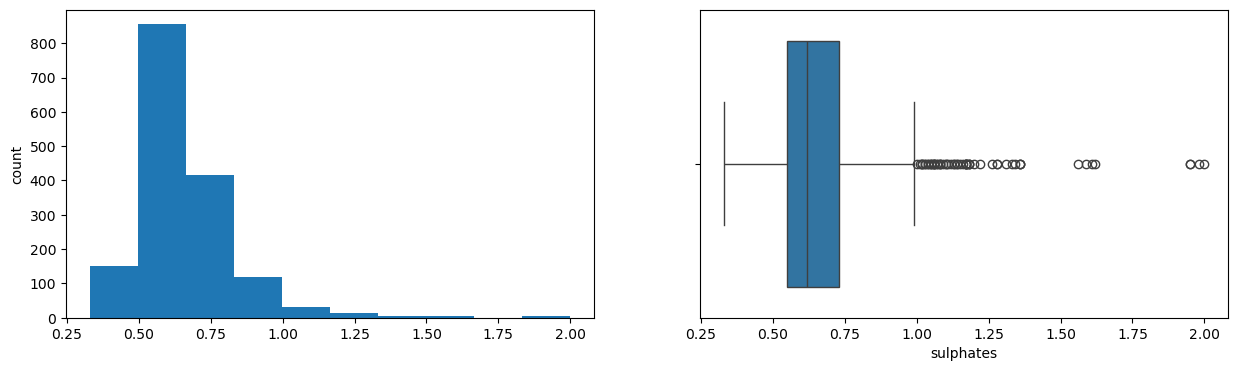

alcohol
Skew : 0.86


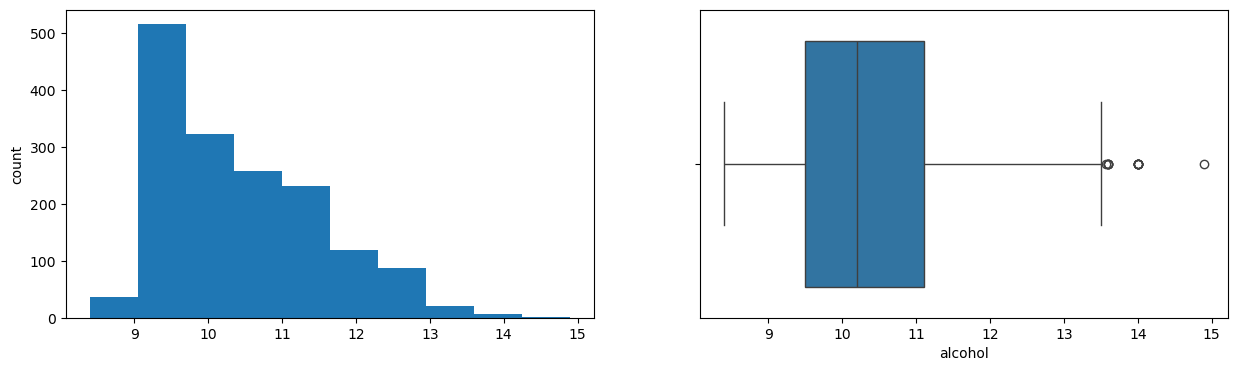

quality
Skew : 0.22


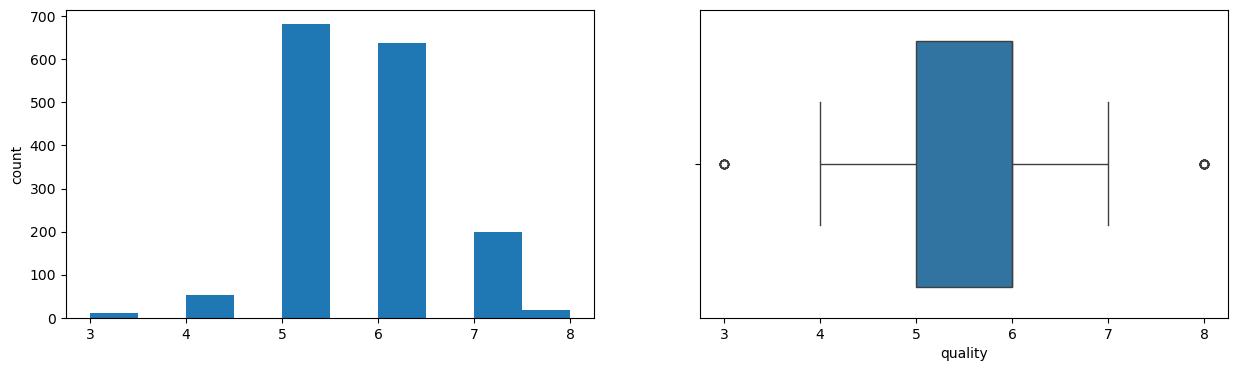

In [13]:
# Check the histogram and boxplot for each numerical feature
num_cols = df_red_raw.select_dtypes(include=np.number).columns.tolist()
for col in num_cols:
    print(col)
    print('Skew :', round(df_red_raw[col].skew(), 2))
    plt.figure(figsize = (15, 4))
    plt.subplot(1, 2, 1)
    df_red_raw[col].hist(grid=False)
    plt.ylabel('count')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_red_raw[col])
    plt.show()

fixed_acidity
Skew : 0.65


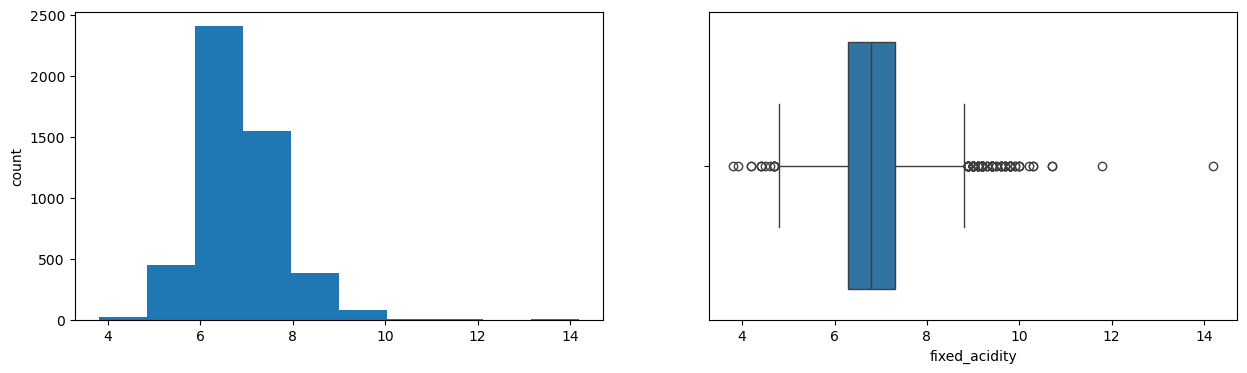

volatile_acidity
Skew : 1.58


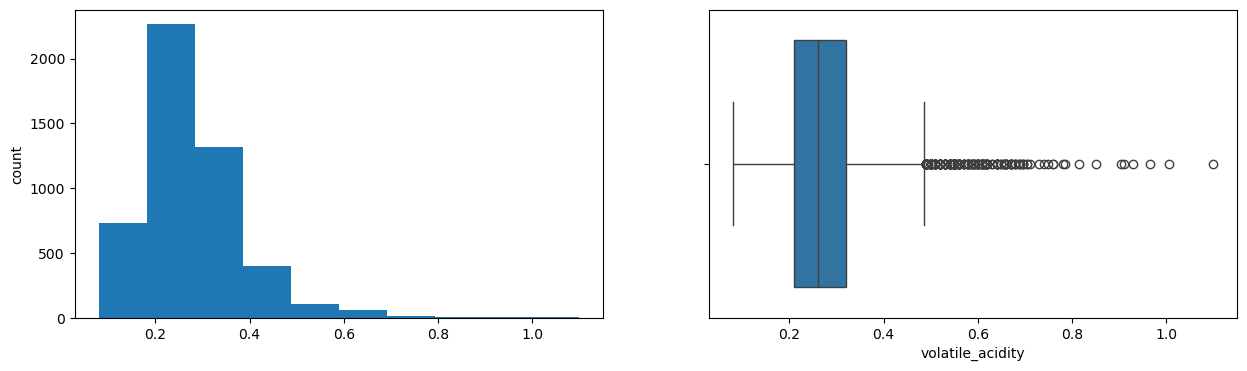

citric_acid
Skew : 1.28


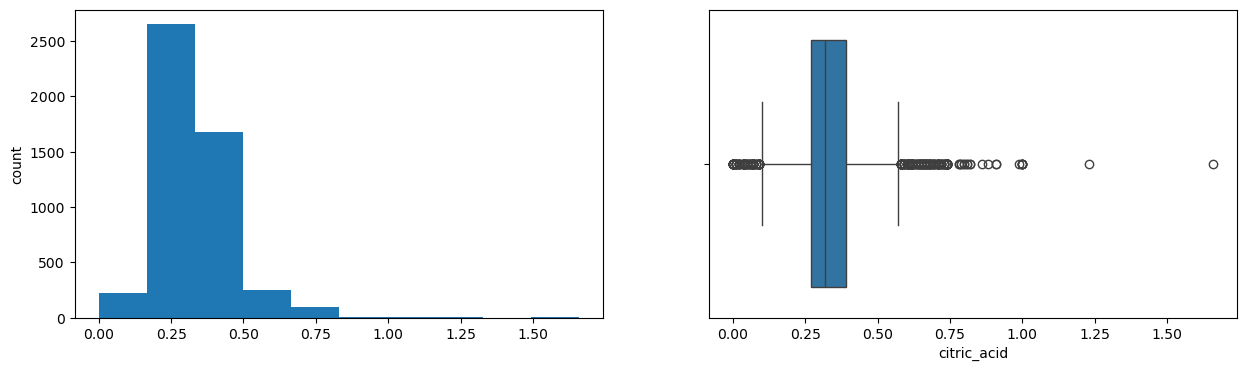

residual_sugar
Skew : 1.08


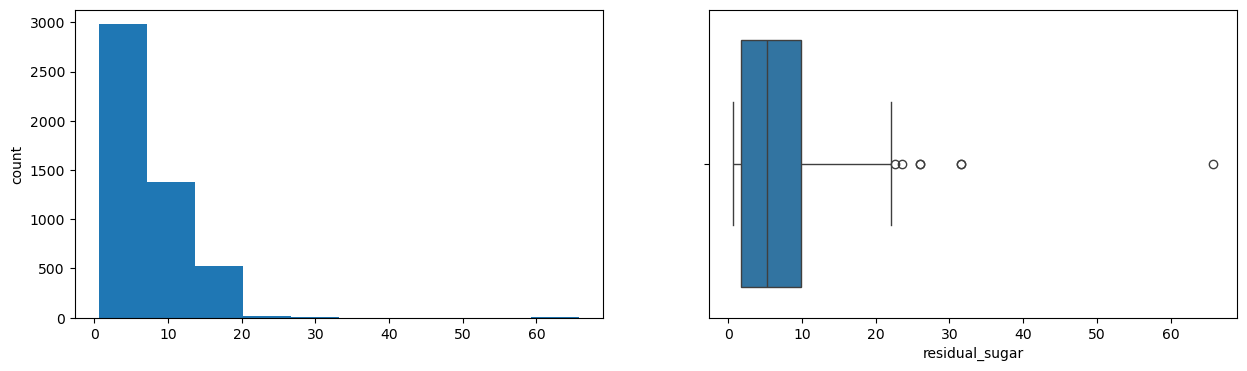

chlorides
Skew : 5.02


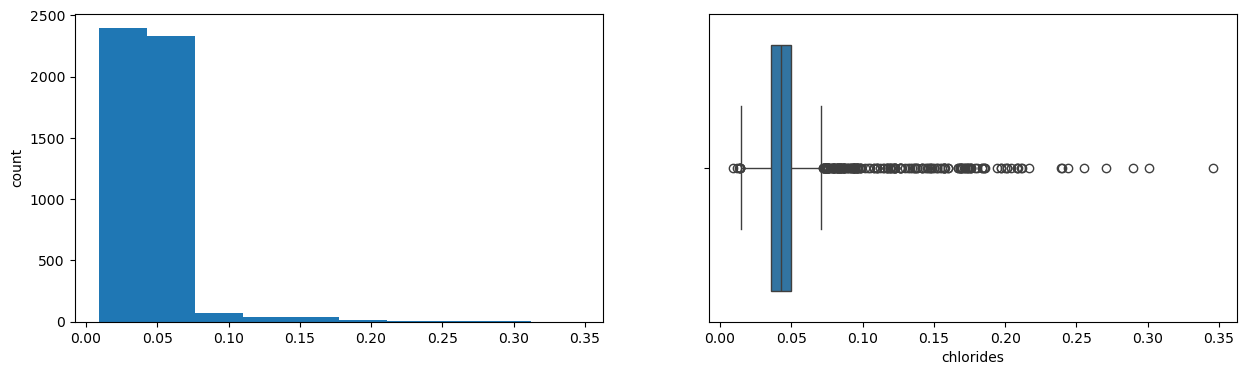

free_sulfur_dioxide
Skew : 1.41


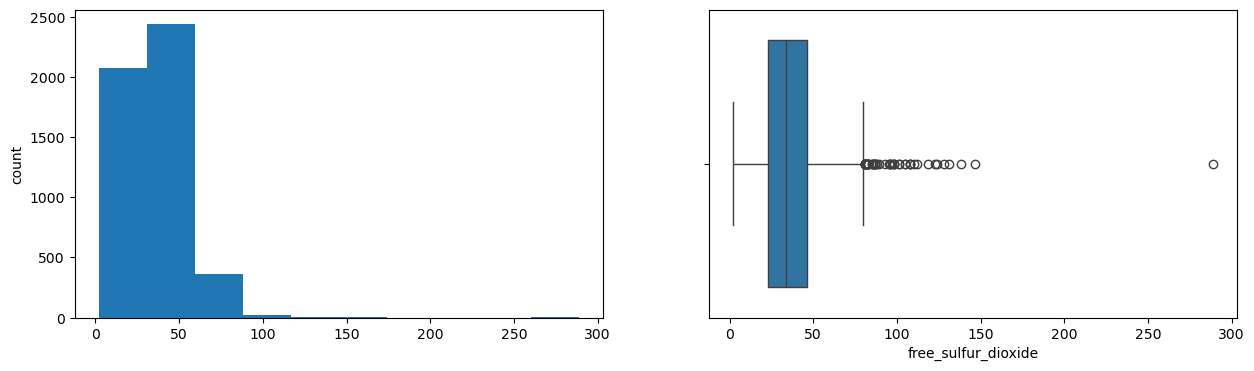

total_sulfur_dioxide
Skew : 0.39


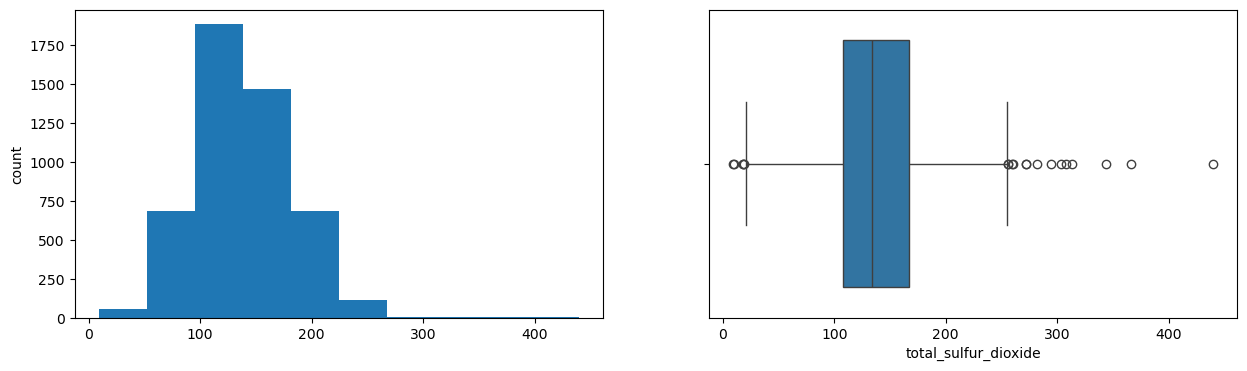

density
Skew : 0.98


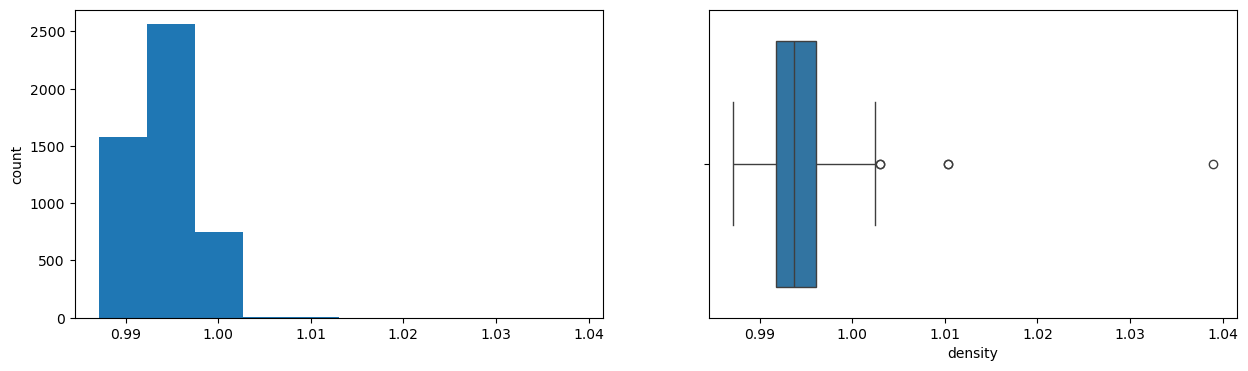

pH
Skew : 0.46


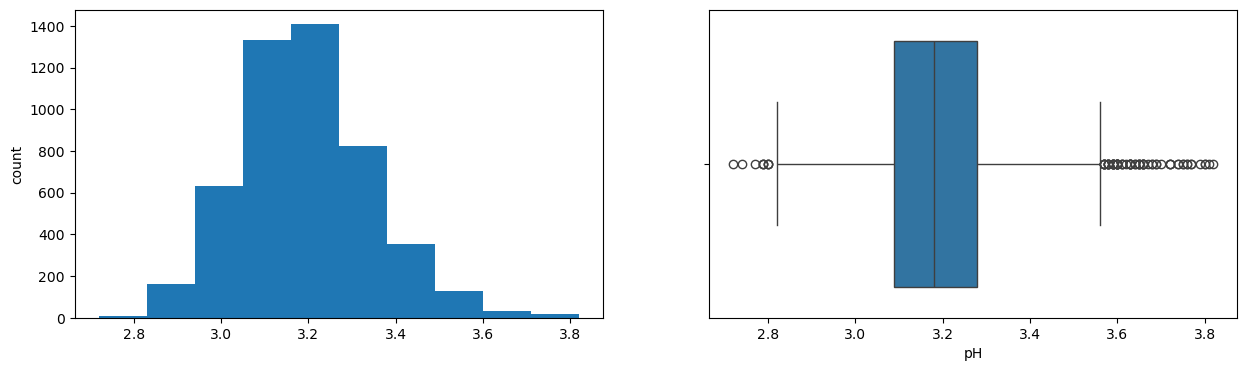

sulphates
Skew : 0.98


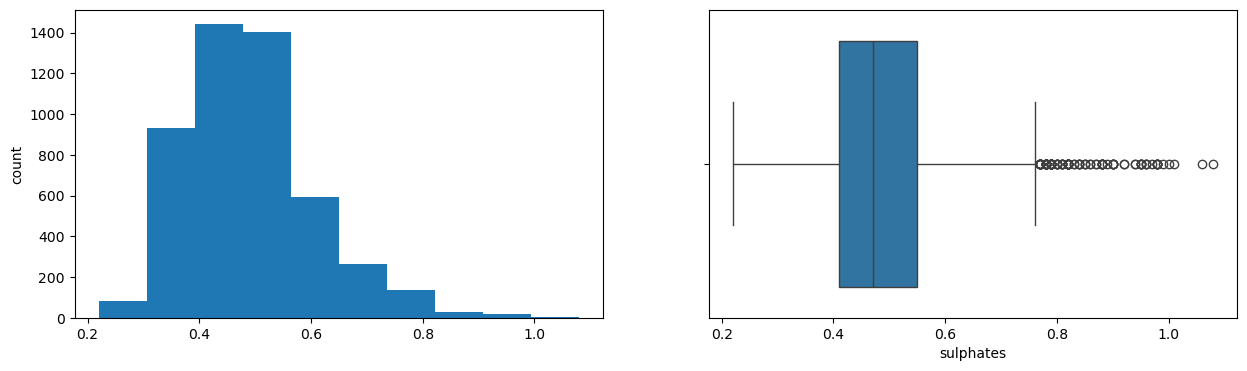

alcohol
Skew : 0.49


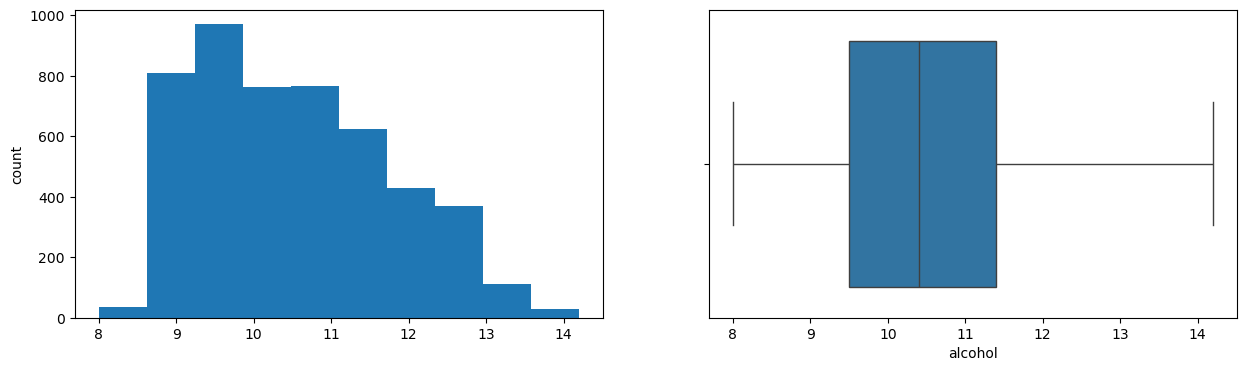

quality
Skew : 0.16


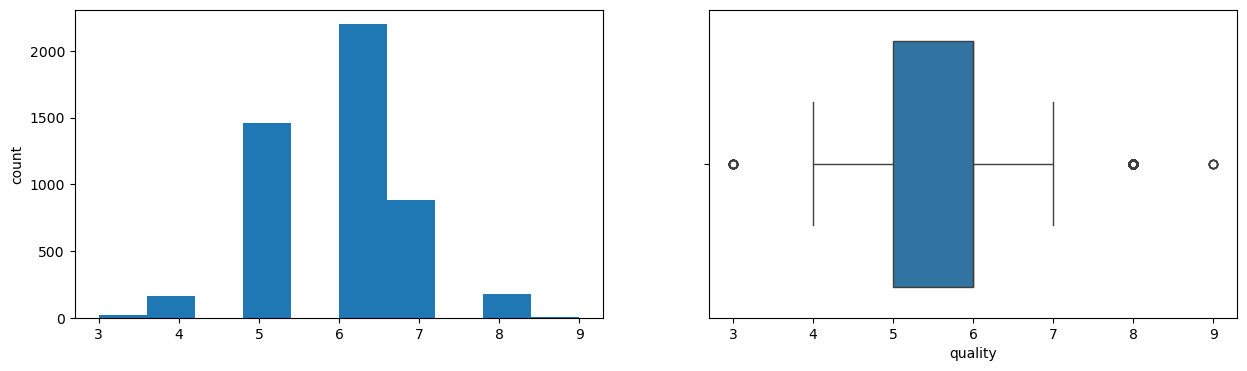

In [14]:
# Univariate analysis
# Check the histogram and boxplot for each numerical feature
num_cols = df_white_raw.select_dtypes(include=np.number).columns.tolist()
for col in num_cols:
    print(col)
    print('Skew :', round(df_white_raw[col].skew(), 2))
    plt.figure(figsize = (15, 4))
    plt.subplot(1, 2, 1)
    df_white_raw[col].hist(grid=False)
    plt.ylabel('count')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_white_raw[col])
    plt.show()

### Outliers Treatment
Box plots indicate the presence of outliers in the data. However, a deeper analysis of the wine's physiochemical composition suggests that while some values are rare, they remain plausible and may reflect quality issues rather than errors. Therefore, only total sulfur dioxide values exceeding 250 in red wines will be removed, as these are likely true outliers.

In [15]:
# Remove values greater than 250 in total_sulfur_dioxide as these are likely outliers
df_red_raw = df_red_raw[df_red_raw['total_sulfur_dioxide'] < 250]  

### Analyzing the target variable

In [16]:
df_red_raw["quality"].value_counts()

quality
5    681
6    638
7    197
4     53
8     18
3     10
Name: count, dtype: int64

In [17]:
df_white_raw["quality"].value_counts()

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

The target variable is highly imbalanced in both datasets and can be simplified.

In [18]:
# Transform target variable by using values low, average, and high. Values 0-4 are low, 5-6 are average, and 7-10 are high.
df_red_raw['quality'] = pd.cut(df_red_raw['quality'], bins=[0, 4, 6, 10], labels=['low', 'average', 'high'])
df_white_raw['quality'] = pd.cut(df_white_raw['quality'], bins=[0, 4, 6, 10], labels=['low', 'average', 'high'])

In [19]:
df_red_raw['quality'].value_counts()

quality
average    1319
high        215
low          63
Name: count, dtype: int64

In [20]:
df_white_raw['quality'].value_counts()

quality
average    3655
high       1060
low         183
Name: count, dtype: int64

Use SMOTE to balance the dataset.

In [21]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the red wine dataset
X_red = df_red_raw.drop('quality', axis=1)
y_red = df_red_raw['quality']
X_red_balanced, y_red_balanced = smote.fit_resample(X_red, y_red)  

# Apply SMOTE to the white wine dataset
X_white = df_white_raw.drop('quality', axis=1)
y_white = df_white_raw['quality']
X_white_balanced, y_white_balanced = smote.fit_resample(X_white, y_white)

# Check the distribution of the target variable after applying SMOTE
print('Red wine quality distribution after SMOTE:')
print(y_red_balanced.value_counts())

print('White wine quality distribution after SMOTE:')
print(y_white_balanced.value_counts())

Red wine quality distribution after SMOTE:
quality
low        1319
average    1319
high       1319
Name: count, dtype: int64
White wine quality distribution after SMOTE:
quality
low        3655
average    3655
high       3655
Name: count, dtype: int64


In [22]:
from sklearn.model_selection import train_test_split

# Split the red wine data into training and testing sets
X_red_train, X_red_test, y_red_train, y_red_test = train_test_split(X_red_balanced, y_red_balanced, test_size=0.2, random_state=42)

# Split the white wine data into training and testing sets
X_white_train, X_white_test, y_white_train, y_white_test = train_test_split(X_white_balanced, y_white_balanced, test_size=0.2, random_state=42)

### Baseline Model

In [23]:
from sklearn.feature_selection import SelectFromModel, SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    # ('poly_features', PolynomialFeatures(degree=2)),
    # ('pca', PCA(n_components=0.95)),
    # ('feature_selection', SelectFromModel(LogisticRegression(random_state=42))),
    ('regressor', LogisticRegression(random_state=42))
])

In [24]:
# Fit and transform the pipeline on the red wine training data
pipeline.fit(X_red_train, y_red_train)
y_red_pred = pipeline.predict(X_red_test)
print('red wine accuracy: ', pipeline.score(X_red_test, y_red_test))

# Fit and transform the pipeline on the white wine training data
pipeline.fit(X_white_train, y_white_train)
y_white_pred = pipeline.predict(X_white_test)
print('white wine accuracy: ', pipeline.score(X_white_test, y_white_test))

red wine accuracy:  0.7247474747474747
white wine accuracy:  0.6329229366165071


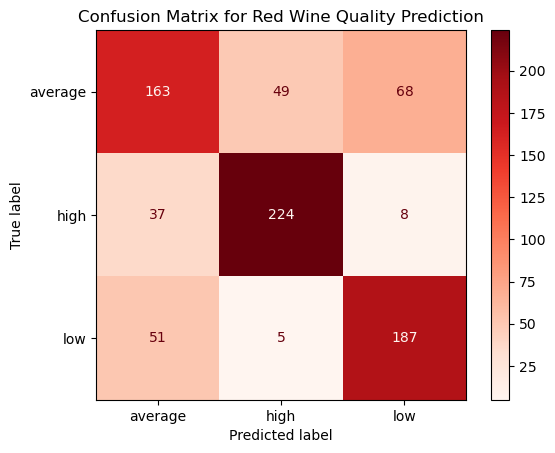

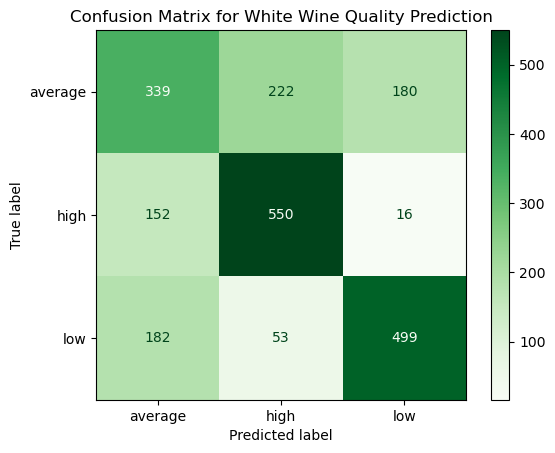

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix for red wine
cm_red = confusion_matrix(y_red_test, y_red_pred)
disp_red = ConfusionMatrixDisplay(confusion_matrix=cm_red, display_labels=np.unique(np.concatenate((y_red_test, y_red_pred))))
disp_red.plot(cmap='Reds')
plt.title('Confusion Matrix for Red Wine Quality Prediction')
plt.show()

# Confusion matrix for white wine
cm_white = confusion_matrix(y_white_test, y_white_pred)
disp_white = ConfusionMatrixDisplay(confusion_matrix=cm_white, display_labels=np.unique(np.concatenate((y_white_test, y_white_pred))))
disp_white.plot(cmap='Greens')
plt.title('Confusion Matrix for White Wine Quality Prediction')
plt.show()

### Exploring Models
We will explore other classifiers to try to beat the baseline model

In [26]:
import time
from sklearn.metrics import accuracy_score

In [30]:
# Initialize models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


models = {
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42)
}

In [31]:
# Evaluate models for red wine
results_red = []
for model_name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    start_time = time.time()
    pipeline.fit(X_red_train, y_red_train)
    end_time = time.time()
    train_time = end_time - start_time
    train_accuracy = accuracy_score(y_red_train, pipeline.predict(X_red_train))
    test_accuracy = accuracy_score(y_red_test, pipeline.predict(X_red_test))
    results_red.append({
        "Model": model_name,
        "Train Time": train_time,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy
    })

In [32]:
# Convert results to DataFrame
results_red_df = pd.DataFrame(results_red)
print("\nModel Comparison for Red Wine:")
print(results_red_df)


Model Comparison for Red Wine:
                    Model  Train Time  Train Accuracy  Test Accuracy
0     K-Nearest Neighbors    0.006343        0.903318       0.871212
1           Decision Tree    0.021441        1.000000       0.866162
2  Support Vector Machine    0.062962        0.874882       0.851010


In [33]:
# Evaluate models for white wine
results_white = []
for model_name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    start_time = time.time()
    pipeline.fit(X_white_train, y_white_train)
    end_time = time.time()
    train_time = end_time - start_time
    train_accuracy = accuracy_score(y_white_train, pipeline.predict(X_white_train))
    test_accuracy = accuracy_score(y_white_test, pipeline.predict(X_white_test))
    results_white.append({
        "Model": model_name,
        "Train Time": train_time,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy
    })

In [34]:
# Convert results to DataFrame
results_white_df = pd.DataFrame(results_white)
print("\nModel Comparison for White Wine:")
print(results_white_df)


Model Comparison for White Wine:
                    Model  Train Time  Train Accuracy  Test Accuracy
0     K-Nearest Neighbors    0.012467        0.895235       0.844961
1           Decision Tree    0.065893        1.000000       0.858185
2  Support Vector Machine    0.508594        0.812244       0.802554


### Hyperparameter Tunning

In [35]:
# Hyperparameter grids
grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100]
    },
    "K-Nearest Neighbors": {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"]
    },
    "Decision Tree": {
        "max_depth": [None, 5, 10, 20],
        "min_samples_split": [2, 5, 10]
    },
    "Support Vector Machine": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"]
    }
}

In [41]:
# Evaluate models with grid search
from sklearn.model_selection import GridSearchCV

hyper_results_red = []
best_models_red = []
for model_name, model in models.items():
    print(f"\nStarting Grid Search for {model_name}...")
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    grid_params = {f'model__{key}': value for key, value in grids[model_name].items()}
    grid = GridSearchCV(pipeline, grid_params, scoring="accuracy", cv=5, n_jobs=-1)
    start_time = time.time()
    grid.fit(X_red_train, y_red_train)
    end_time = time.time()
    train_time = end_time - start_time
    best_model = grid.best_estimator_
    best_models_red.append({
        "Model name": model_name,
        "Model": best_model
    })
    train_accuracy = accuracy_score(y_red_train, best_model.predict(X_red_train))
    test_accuracy = accuracy_score(y_red_test, best_model.predict(X_red_test))
    hyper_results_red.append({
        "Model": model_name,
        "Best Params": grid.best_params_,
        "Train Time": train_time,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy
    })
    print(f"Best parameters for {model_name}: {grid.best_params_}")


Starting Grid Search for K-Nearest Neighbors...
Best parameters for K-Nearest Neighbors: {'model__n_neighbors': 3, 'model__weights': 'distance'}

Starting Grid Search for Decision Tree...
Best parameters for Decision Tree: {'model__max_depth': None, 'model__min_samples_split': 2}

Starting Grid Search for Support Vector Machine...
Best parameters for Support Vector Machine: {'model__C': 10, 'model__kernel': 'rbf'}


In [42]:
# Convert results to DataFrame
hyper_results_red_df = pd.DataFrame(hyper_results_red)
print("\nModel Comparison with Hyperparameter Tuning for Red Wines:")
print(hyper_results_red_df.iloc[0:])


Model Comparison with Hyperparameter Tuning for Red Wines:
                    Model                                        Best Params  \
0     K-Nearest Neighbors  {'model__n_neighbors': 3, 'model__weights': 'd...   
1           Decision Tree  {'model__max_depth': None, 'model__min_samples...   
2  Support Vector Machine           {'model__C': 10, 'model__kernel': 'rbf'}   

   Train Time  Train Accuracy  Test Accuracy  
0    1.795317        1.000000       0.893939  
1    0.191091        1.000000       0.866162  
2    0.574934        0.947867       0.914141  


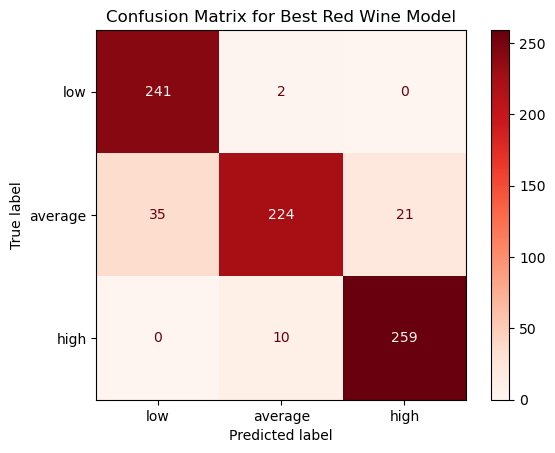

In [49]:
# Confusion matrix for best model
best_model_red = best_models_red[2]['Model']
y_red_best_pred = best_model_red.predict(X_red_test)
cm_red_best = confusion_matrix(y_red_test, y_red_best_pred, labels=['low', 'average', 'high'])
disp_red_best = ConfusionMatrixDisplay(confusion_matrix=cm_red_best, display_labels=['low', 'average', 'high'])
disp_red_best.plot(cmap='Reds')
plt.title('Confusion Matrix for Best Red Wine Model')
plt.show()

In [46]:
# Evaluate models with grid search for white wine
hyper_results_white = []
best_models_white = []
for model_name, model in models.items():
    print(f"\nStarting Grid Search for {model_name}...")
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    grid_params = {f'model__{key}': value for key, value in grids[model_name].items()}
    grid = GridSearchCV(pipeline, grid_params, scoring="accuracy", cv=5, n_jobs=-1)
    start_time = time.time()
    grid.fit(X_white_train, y_white_train)
    end_time = time.time()
    train_time = end_time - start_time
    best_model = grid.best_estimator_
    best_models_white.append({
        "Model name": model_name,
        "Model": best_model
    })
    train_accuracy = accuracy_score(y_white_train, best_model.predict(X_white_train))
    test_accuracy = accuracy_score(y_white_test, best_model.predict(X_white_test))
    hyper_results_white.append({
        "Model": model_name,
        # "Best Params": grid.best_params_,
        "Train Time": train_time,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy
    })
    print(f"Best parameters for {model_name}: {grid.best_params_}")


Starting Grid Search for K-Nearest Neighbors...
Best parameters for K-Nearest Neighbors: {'model__n_neighbors': 3, 'model__weights': 'distance'}

Starting Grid Search for Decision Tree...
Best parameters for Decision Tree: {'model__max_depth': 20, 'model__min_samples_split': 2}

Starting Grid Search for Support Vector Machine...
Best parameters for Support Vector Machine: {'model__C': 10, 'model__kernel': 'rbf'}


In [47]:
# Convert results to DataFrame
hyper_results_white_df = pd.DataFrame(hyper_results_white)
print("\nModel Comparison with Hyperparameter Tuning for White Wines:")
print(hyper_results_white_df)


Model Comparison with Hyperparameter Tuning for White Wines:
                    Model  Train Time  Train Accuracy  Test Accuracy
0     K-Nearest Neighbors    0.339484        1.000000       0.899225
1           Decision Tree    0.444140        0.993388       0.858185
2  Support Vector Machine    5.057998        0.891131       0.851345


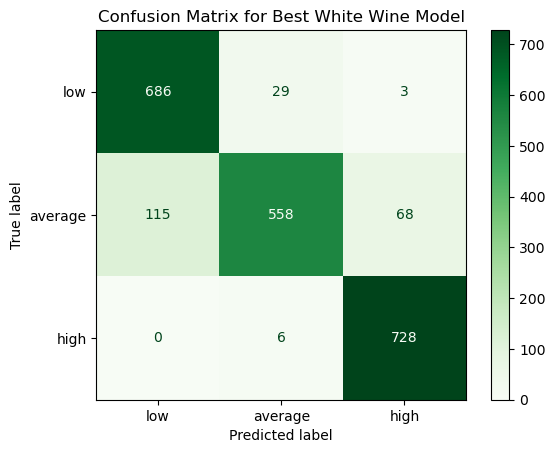

In [57]:
# Confusion matrix for best model for white wine
best_model_white = best_models_white[0]['Model']
y_white_best_pred = best_model_white.predict(X_white_test)
cm_white_best = confusion_matrix(y_white_test, y_white_best_pred, labels=['high', 'average', 'low'])
disp_white_best = ConfusionMatrixDisplay(confusion_matrix=cm_white_best, display_labels=['low', 'average', 'high'])
disp_white_best.plot(cmap='Greens')
plt.title('Confusion Matrix for Best White Wine Model')
plt.show()